## Présentation [OpenDC](https://www.open-dc.com/fr/)


<table>
<tr>
<td style="vertical-align: top; width: 50%;">

* Entreprise créée en janvier 2019

* Expertise en:
    * Modélisation des transports / flux piétons
    * Analyse et gestion de la donnée
    * Automatisation de process
    * Modélisation mathématique
    * Développement web
<br>

* Activités annexes:
    * Chargé de TD en cours de [`Python` pour la data science](https://pythonds.linogaliana.fr/) à l'ENSAE ![ensae](./img/logo_ensae.png)
    * Employé du COJO Paris 2024 équipe transports en 2023-2024 ![p24](./img/logo_P24.png)

</td>
<td style="vertical-align: top; width: 50%;">

<div>
  <img src="./img/sectors_openDC.svg" width="400"/>
</div>


</td>
</tr>
</table>





## Sommaire

* [Exemple de manipulations habituelles sous `QGIS` + `Excel`](#exemple-de-manipulations-habituelles-sous-qgis--excel)
* [Développer sur `Python`: quoi, pourquoi et comment](#développer-sur-python-pourquoi-et-comment)
* [Présentation des `Notebook Jupyter`](#présentation-des-notebook-jupyter)
* [Reprise des manipulations `QGIS` / `Excel` sous `Notebook`](#reprise-des-manipulations-qgis--excel-sous-notebook)
* [Synthèse des outils recommandés par type et taille de fichier](#synthèse-des-outils-recommandés-par-type-et-taille-de-fichier)
* [Pour aller plus loin](#pour-aller-plus-loin)


## Exemple de manipulations habituelles sous `QGIS` + `Excel`

### Cas d'usage

Pour un diagnostic territorial, on souhaite connaitre la population de notre territoire se trouvant à moins de 800m d'une station de transports en commun (TC).

### Manipulation habituelle (exemple sur la métropole de Lyon)

<table>
<tr>
<td style="vertical-align: top; padding-right: 16px; width: 50%;">


1. **Téléchargement** des arrêts de TC sur le [site de la métropole][site_metro].
2. [**Téléchargement** des contours IRIS sur le site de l'IGN][site_ign].
3. [**Téléchargement** des données de population à l'IRIS sur le site de l'INSEE][site_insee].
4. Ouverture sur `QGIS` des arrêts TC et des contours IRIS.
5. Export éventuel des seuls contours IRIS qui nous intéressent afin de rendre le process plus léger.
6. Ouverture des données de Population sous `Excel` afin de déterminer les clés de communication entre la couche IGN et la couche INSEE.
7. **Jointure atttributaire** sous QGIS pour lier la population aux contours d'IRIS.
8. Création d'un ***tampon*** (*buffer*) de `800m` autour des stations TC sur `QGIS`.
9. **Jointure par localisation** sous `QGIS` pour associer les *tampons* aux IRIS qu'ils couvrent.
10. **Export de la jointure** sous `Excel` pour extraire les populations par IRIS, éventuellement au prorata des surfaces recoupées.

</td>
<td style="vertical-align: top; width: 50%;">

<div>
  <img src="./img/xls_qgis_demo.jpg" width="400"/>
</div>

</td>
</tr>
</table>

[site_metro]: https://data.grandlyon.com/portail/fr/jeux-de-donnees/entrees-sorties-stations-metro-reseau-transports-commun-lyonnais/telechargements
[site_ign]: https://www.google.com/url?q=https%3A%2F%2Fdata.geopf.fr%2Ftelechargement%2Fdownload%2FCONTOURS-IRIS-PE%2FCONTOURS-IRIS-PE_3-0__GPKG_LAMB93_FXX_2025-01-01%2FCONTOURS-IRIS-PE_3-0__GPKG_LAMB93_FXX_2025-01-01.7z
[site_insee]: https://www.insee.fr/fr/statistiques/8647014

## Développer sur `Python`: quoi, pourquoi et comment

![python_logo](./img/python_full.png)

## Quoi

* `Python` est un langage de programmation (à l'instar de `C`, `C++`, `Javascript`, `R`, `VBA` et des centaines, voire des milliers d'autres).

*Exemples de syntaxe de langages*

<table>
<tr>

<td>

`Python`

</td>

<td>

`C`

</td>

<td>

`R`

</td>

</tr>
<tr>
<td style="vertical-align: top; width: 33%;">

```python
def square(x):
    return x * x

print(square(5))
```

</td>
<td style="vertical-align: top; width: 33%;">

```c
#include <stdio.h>

int square(int x) {
    return x * x;
}

int main() {
    printf("%d\n", square(5));
    return 0;
}
```

</td>
<td style="vertical-align: top; width: 33%;">

```r
square <- function(x) {
  x * x
}

print(square(5))

```

</td>
</tr>
</table>


## Pourquoi

* `Python` s'utilise de l'exacte (ou presque) même manière sur `Windows`, `Mac` ou `Linux`.
* `Python` est gratuit et Open Source
* Populaire (grand nombre de développeurs et libraires).
* Flexible et simple à apprendre.
* Exécution rapide au regard des faibles contraintes de programmation.
* `Python` permet de communiquer avec à peu près tout (`QGIS`, l'immense majorité des `API`, `Microsoft Azure`, `Google Cloud Platform` etc.)



## Présentation des `Notebook Jupyter`

### Présentation générale

TODO

### Exemples


In [1]:
# # Commandes simples:
print('ok')

ok


In [17]:
# # Affichage de données:
import pandas as pd

df = pd.read_csv('https://storage.googleapis.com/public-bucket-tests/GIS/populations_regions_france_2026.csv')
df.head()

,Code région,Nom de la région,Population municipale
0,84,Auvergne-Rhône-Alpes,8205557
1,27,Bourgogne-Franche-Comté,2802670
2,53,Bretagne,3449370
3,24,Centre-Val de Loire,2587031
4,94,Corse,355486


<Axes: xlabel='Nom de la région'>

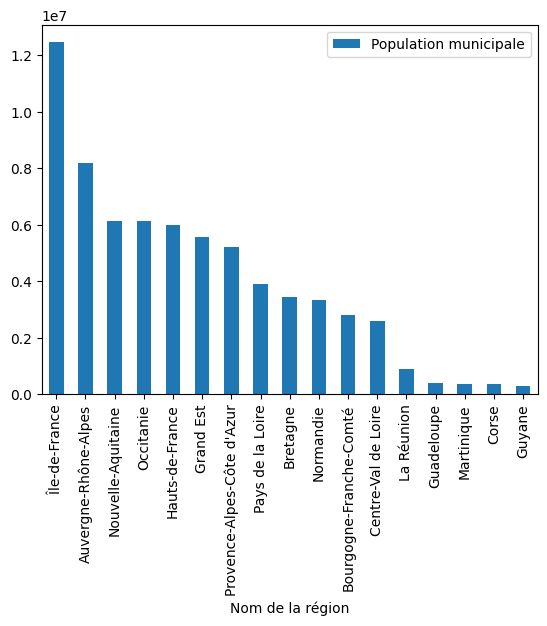

In [22]:
# # Affichage de graphiques:
df.sort_values(by='Population municipale', ascending=False, inplace=True)
df.plot.bar(x='Nom de la région', y='Population municipale')

Code région              int64
Nom de la région           str
Population municipale    int64
dtype: object
region                str
code                int32
geometry         geometry
geometry_bbox      object
dtype: object


<Axes: >

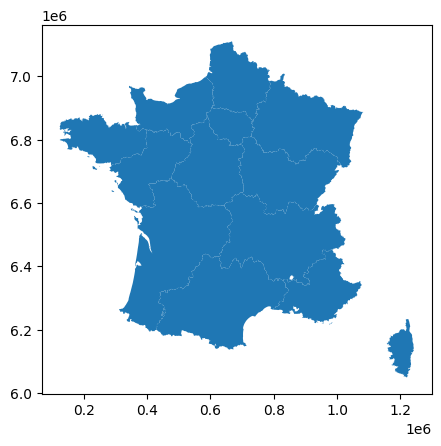

In [33]:
# # Affichage de cartes:
import geopandas as gpd
from shapely import wkb

gdf = pd.read_parquet('https://storage.googleapis.com/public-bucket-tests/GIS/regions_france.parquet')
gdf['geometry'] = gdf['geometry'].apply(wkb.loads)
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs='EPSG:2154')
print(df.dtypes)
print(gdf.dtypes)
gdf = gdf.merge(df, left_on='code', right_on='Code région', how='left')
gdf.plot()

## Reprise des manipulations `QGIS` / `Excel` sous `Notebook`

TODO


In [ ]:
%%sql


## Synthèse des outils recommandés par type et taille de fichier

TODO


## Pour aller plus loin

TODO